<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/06_banking_asset_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Table 1: Core Balance Sheet Volume (₹ in Crores)
balance_sheet_data = """Bank,Sector,Total_Deposits_Cr,Gross_Advances_Cr
State Bank of India,PSB,4916000,3767000
Punjab National Bank,PSB,1450000,1020000
Bank of Baroda,PSB,1325000,1040000
Canara Bank,PSB,1260000,960000
HDFC Bank,Private,2380000,2510000
ICICI Bank,Private,1498000,1342000
Axis Bank,Private,1060000,965000
Kotak Mahindra Bank,Private,445000,391000
"""

# Table 2: Asset Quality & Bad Loans (₹ in Crores)
asset_quality_data = """Bank,Gross_NPA_Cr,Net_NPA_Cr,Provisions_Cr
State Bank of India,84000,19965,64035
Punjab National Bank,40290,4080,36210
Bank of Baroda,29120,6240,22880
Canara Bank,34560,8640,25920
HDFC Bank,34136,8785,25351
ICICI Bank,21472,5368,16104
Axis Bank,13896,4053,9843
Kotak Mahindra Bank,5474,1368,4106
"""

with open("bank_balance_sheets.csv", "w") as f:
    f.write(balance_sheet_data.strip())

with open("bank_asset_quality.csv", "w") as f:
    f.write(asset_quality_data.strip())

print("Datasets created successfully.")

Datasets created successfully.


In [2]:
# Read both files and perform an inner join on the 'Bank' column
df_balances = pd.read_csv("bank_balance_sheets.csv")
df_npa = pd.read_csv("bank_asset_quality.csv")

df_bank_audit = pd.merge(df_balances, df_npa, on="Bank", how="inner")

print("--- Merged Bank Profile Table ---")
print(df_bank_audit)

--- Merged Bank Profile Table ---
                   Bank   Sector  Total_Deposits_Cr  Gross_Advances_Cr  \
0   State Bank of India      PSB            4916000            3767000   
1  Punjab National Bank      PSB            1450000            1020000   
2        Bank of Baroda      PSB            1325000            1040000   
3           Canara Bank      PSB            1260000             960000   
4             HDFC Bank  Private            2380000            2510000   
5            ICICI Bank  Private            1498000            1342000   
6             Axis Bank  Private            1060000             965000   
7   Kotak Mahindra Bank  Private             445000             391000   

   Gross_NPA_Cr  Net_NPA_Cr  Provisions_Cr  
0         84000       19965          64035  
1         40290        4080          36210  
2         29120        6240          22880  
3         34560        8640          25920  
4         34136        8785          25351  
5         21472        5368  

In [3]:
# Gross NPA Ratio (%)
df_bank_audit["GNPA_Ratio_%"] = (
    df_bank_audit["Gross_NPA_Cr"] / df_bank_audit["Gross_Advances_Cr"]
) * 100

# Net NPA Ratio (%)
df_bank_audit["NNPA_Ratio_%"] = (
    df_bank_audit["Net_NPA_Cr"] / df_bank_audit["Gross_Advances_Cr"]
) * 100

# Provision Coverage Ratio (PCR %)
df_bank_audit["PCR_%"] = (
    df_bank_audit["Provisions_Cr"] / df_bank_audit["Gross_NPA_Cr"]
) * 100

# Credit-to-Deposit Ratio (C-D %)
df_bank_audit["CD_Ratio_%"] = (
    df_bank_audit["Gross_Advances_Cr"] / df_bank_audit["Total_Deposits_Cr"]
) * 100

# Sort descending by GNPA Ratio
df_bank_audit = df_bank_audit.sort_values(
    by="GNPA_Ratio_%", ascending=False
).reset_index(drop=True)

print("--- Regulatory Asset Quality Metrics ---")
print(
    df_bank_audit[
        ["Bank", "Sector", "GNPA_Ratio_%", "NNPA_Ratio_%", "PCR_%", "CD_Ratio_%"]
    ].round(2)
)

--- Regulatory Asset Quality Metrics ---
                   Bank   Sector  GNPA_Ratio_%  NNPA_Ratio_%  PCR_%  \
0  Punjab National Bank      PSB          3.95          0.40  89.87   
1           Canara Bank      PSB          3.60          0.90  75.00   
2        Bank of Baroda      PSB          2.80          0.60  78.57   
3   State Bank of India      PSB          2.23          0.53  76.23   
4            ICICI Bank  Private          1.60          0.40  75.00   
5             Axis Bank  Private          1.44          0.42  70.83   
6   Kotak Mahindra Bank  Private          1.40          0.35  75.01   
7             HDFC Bank  Private          1.36          0.35  74.26   

   CD_Ratio_%  
0       70.34  
1       76.19  
2       78.49  
3       76.63  
4       89.59  
5       91.04  
6       87.87  
7      105.46  


In [4]:
sector_summary = (
    df_bank_audit.groupby("Sector")
    .agg(
        Total_Advances=("Gross_Advances_Cr", "sum"),
        Total_Deposits=("Total_Deposits_Cr", "sum"),
        Total_GNPA=("Gross_NPA_Cr", "sum"),
        Total_Provisions=("Provisions_Cr", "sum"),
    )
)

# Weighted systemic ratios
sector_summary["Weighted_GNPA_%"] = (
    sector_summary["Total_GNPA"] / sector_summary["Total_Advances"]
) * 100
sector_summary["Weighted_PCR_%"] = (
    sector_summary["Total_Provisions"] / sector_summary["Total_GNPA"]
) * 100
sector_summary["Weighted_CD_%"] = (
    sector_summary["Total_Advances"] / sector_summary["Total_Deposits"]
) * 100

print("--- PSB vs. Private Sector Summary ---")
print(
    sector_summary[
        ["Total_Advances", "Weighted_GNPA_%", "Weighted_PCR_%", "Weighted_CD_%"]
    ].round(2)
)

--- PSB vs. Private Sector Summary ---
         Total_Advances  Weighted_GNPA_%  Weighted_PCR_%  Weighted_CD_%
Sector                                                                 
PSB             6787000             2.77           79.29          75.82
Private         5208000             1.44           73.89          96.75


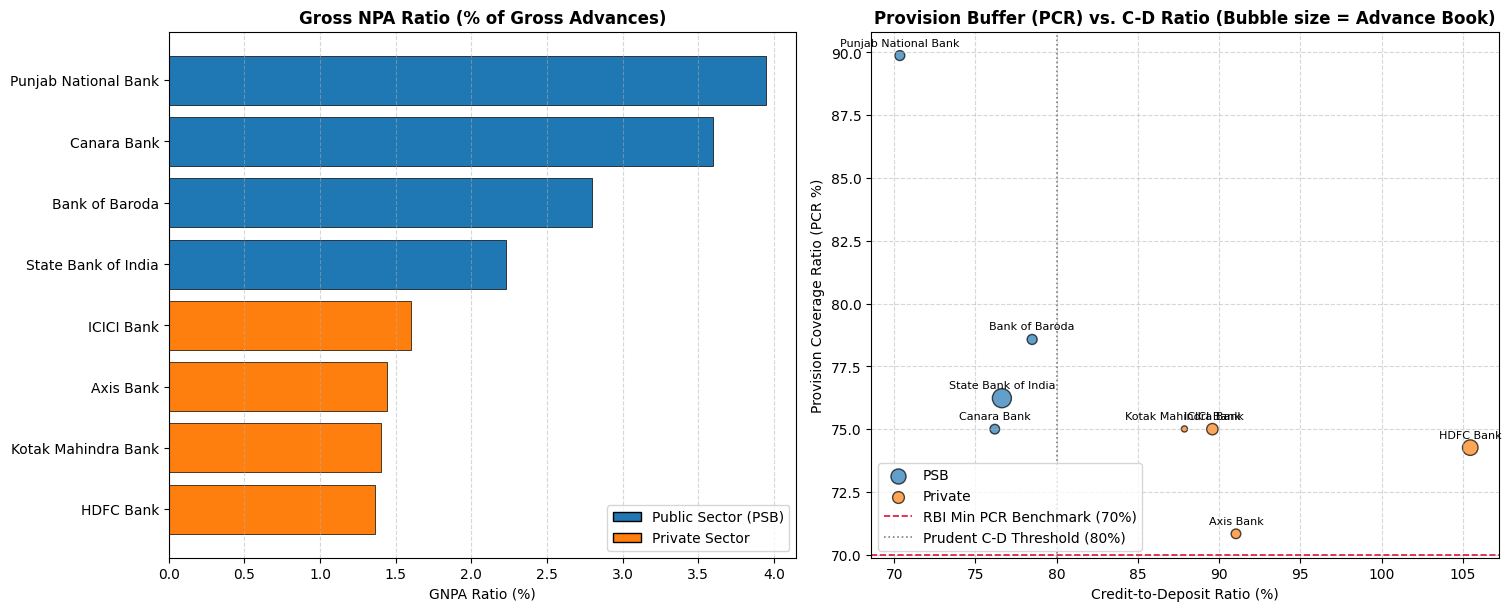

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")

# --- Chart 1: Gross NPA Ratio by Bank ---
df_sorted = df_bank_audit.sort_values(by="GNPA_Ratio_%")
bar_colors = [
    "#1f77b4" if s == "PSB" else "#ff7f0e" for s in df_sorted["Sector"]
]

ax1.barh(
    df_sorted["Bank"],
    df_sorted["GNPA_Ratio_%"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5,
)
ax1.set_title("Gross NPA Ratio (% of Gross Advances)", fontsize=12, weight="bold")
ax1.set_xlabel("GNPA Ratio (%)")
ax1.grid(axis="x", linestyle="--", alpha=0.5)

legend_elements = [
    mpatches.Patch(facecolor="#1f77b4", edgecolor="black", label="Public Sector (PSB)"),
    mpatches.Patch(facecolor="#ff7f0e", edgecolor="black", label="Private Sector"),
]
ax1.legend(handles=legend_elements, loc="lower right")

# --- Chart 2: Provision Buffer (PCR) vs. C-D Ratio ---
for sector, color in [("PSB", "#1f77b4"), ("Private", "#ff7f0e")]:
    subset = df_bank_audit[df_bank_audit["Sector"] == sector]
    ax2.scatter(
        subset["CD_Ratio_%"],
        subset["PCR_%"],
        s=subset["Gross_Advances_Cr"] / 20000,
        color=color,
        alpha=0.7,
        edgecolor="black",
        label=sector,
    )
    for _, row in subset.iterrows():
        ax2.annotate(
            row["Bank"],
            (row["CD_Ratio_%"], row["PCR_%"]),
            textcoords="offset points",
            xytext=(0, 7),
            ha="center",
            fontsize=8,
        )

ax2.axhline(
    70.0,
    color="crimson",
    linestyle="--",
    linewidth=1.2,
    label="RBI Min PCR Benchmark (70%)",
)
ax2.axvline(
    80.0,
    color="gray",
    linestyle=":",
    linewidth=1.2,
    label="Prudent C-D Threshold (80%)",
)

ax2.set_title(
    "Provision Buffer (PCR) vs. C-D Ratio (Bubble size = Advance Book)",
    fontsize=12,
    weight="bold",
)
ax2.set_xlabel("Credit-to-Deposit Ratio (%)")
ax2.set_ylabel("Provision Coverage Ratio (PCR %)")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="lower left")

plt.show()